# NB06 — Ensemble (weighted + stacking + logit adjustment)

Fuses the NB05 per-run logits into the final system, reported on the **pure 20% test**:
1. **Confidence-weighted logit ensemble** — weights optimised on val (macro-F1).
2. **Logit adjustment** (Menon 2021) — τ tuned on val, applied to the weighted ensemble.
3. **Stacking meta-learner** — logistic regression over stacked per-run probabilities.

The system that wins on **val** is reported on test (selection on val, eval on the untouched 20% test).
`none`-class F1 is the binary-equivalent. No test data is used for any tuning → no leakage.


In [1]:
import os, json, glob
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, accuracy_score, matthews_corrcoef,
                             roc_auc_score, classification_report, confusion_matrix)

MODELS_DIR = "../outputs/models_main"; SPLIT_DIR = "../data/splits"
OUT = "../outputs/ensemble"; os.makedirs(OUT, exist_ok=True)
LABEL = "label5"
label_enc = json.load(open(f"{MODELS_DIR}/label_encoder.json"))
classes = sorted(label_enc, key=lambda k: label_enc[k]); NC = len(classes)
print("classes:", label_enc)

classes: {'abusive': 0, 'none': 1, 'religious': 2, 'sexual': 3, 'threat': 4}


In [2]:
# ── Load per-run logits (raw tensors [N, 5]) + labels ───────────────────────
val_df  = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")
y_val  = val_df[LABEL].map(label_enc).values
y_test = test_df[LABEL].map(label_enc).values

runs, val_logits, test_logits = [], {}, {}
for d in sorted(glob.glob(f"{MODELS_DIR}/*_seed*")):
    n = os.path.basename(d)
    vp, tp = f"{d}/val_logits.pt", f"{d}/test_logits.pt"
    if os.path.exists(vp) and os.path.exists(tp):
        v = torch.load(vp, map_location="cpu", weights_only=False).float()
        t = torch.load(tp, map_location="cpu", weights_only=False).float()
        if v.shape[0] == len(val_df) and t.shape[0] == len(test_df):
            runs.append(n); val_logits[n] = v; test_logits[n] = t
        else:
            print(f"⚠ skip {n}: shape mismatch v{tuple(v.shape)} t{tuple(t.shape)}")
print(f"Loaded {len(runs)} runs: {runs}")
assert runs, "no runs found — train NB05 first"

Loaded 12 runs: ['banglabert_seed123', 'banglabert_seed42', 'banglabert_seed456', 'banglishbert_seed123', 'banglishbert_seed42', 'banglishbert_seed456', 'muril_seed123', 'muril_seed42', 'muril_seed456', 'xlmr_seed123', 'xlmr_seed42', 'xlmr_seed456']


In [3]:
# ── Script-aware run masks ─────────────────────────────────────────────────
# BanglaBERT was trained/evaluated only on Bangla-script rows.
# During ensemble, BanglaBERT receives zero weight on Romanized rows.
# Other models remain active on all rows.

def is_banglabert_run(name):
    # Match banglabert_seed42, banglabert_seed123, etc.
    # Do NOT match banglishbert.
    return name.startswith("banglabert_seed")

if "script" in val_df.columns and "script" in test_df.columns:
    val_is_bangla = torch.tensor(
        val_df["script"].astype(str).str.lower().eq("bangla").values,
        dtype=torch.bool,
    )
    test_is_bangla = torch.tensor(
        test_df["script"].astype(str).str.lower().eq("bangla").values,
        dtype=torch.bool,
    )
else:
    print("⚠ script column missing; all model logits will be active on all rows.")
    val_is_bangla = torch.ones(len(val_df), dtype=torch.bool)
    test_is_bangla = torch.ones(len(test_df), dtype=torch.bool)

val_masks, test_masks = {}, {}

for n in runs:
    if is_banglabert_run(n):
        val_masks[n] = val_is_bangla.clone()
        test_masks[n] = test_is_bangla.clone()

        # Safety: force neutral logits on Romanized rows even if NB05 already did it.
        val_logits[n] = val_logits[n].clone()
        test_logits[n] = test_logits[n].clone()
        val_logits[n][~val_masks[n]] = 0.0
        test_logits[n][~test_masks[n]] = 0.0

        print(
            f"script-mask {n}: active only on Bangla rows | "
            f"val={int(val_masks[n].sum())}/{len(val_masks[n])}, "
            f"test={int(test_masks[n].sum())}/{len(test_masks[n])}"
        )
    else:
        val_masks[n] = torch.ones(len(val_df), dtype=torch.bool)
        test_masks[n] = torch.ones(len(test_df), dtype=torch.bool)

script-mask banglabert_seed123: active only on Bangla rows | val=5757/9432, test=11406/18865
script-mask banglabert_seed42: active only on Bangla rows | val=5757/9432, test=11406/18865
script-mask banglabert_seed456: active only on Bangla rows | val=5757/9432, test=11406/18865


In [4]:
# ── Weighted-logit ensemble + row-wise script-aware weight optimisation ─────
def ens(logd, w, maskd):
    """
    Row-wise masked weighted ensemble.

    For BanglaBERT:
      Bangla rows    -> normal weight
      Romanized rows -> zero weight

    For all other models:
      all rows -> normal weight
    """
    first = next(iter(logd.values()))
    out = torch.zeros_like(first)
    denom = torch.zeros((first.shape[0], 1), dtype=first.dtype)

    for i, n in enumerate(runs):
        m = maskd.get(n, torch.ones(first.shape[0], dtype=torch.bool))
        m = m.to(dtype=first.dtype).view(-1, 1)

        out += float(w[i]) * m * logd[n]
        denom += float(w[i]) * m

    return out / denom.clamp_min(1e-12)


def optimise_weights(logd, y, maskd, restarts=40):
    k = len(runs)

    def neg(rw):
        w = np.abs(rw) + 1e-9
        pred = ens(logd, w, maskd).argmax(-1).numpy()
        return -f1_score(y, pred, average="macro", zero_division=0)

    best, bw = 1.0, np.ones(k) / k

    for _ in range(restarts):
        r = minimize(
            neg,
            np.random.dirichlet(np.ones(k)),
            method="Nelder-Mead",
            options={"maxiter": 2000, "xatol": 1e-5, "fatol": 1e-6},
        )
        if r.fun < best:
            best, bw = r.fun, np.abs(r.x) + 1e-9

    return bw / bw.sum(), -best


W, val_w_f1 = optimise_weights(val_logits, y_val, val_masks)

print("Ensemble weights (val-optimised; BanglaBERT row-masked on Romanized rows):")
for n, w in zip(runs, W):
    print(f"  {n:22s} {w:.4f}")

print(f"VAL weighted-ensemble macro-F1: {val_w_f1:.4f}")

Ensemble weights (val-optimised; BanglaBERT row-masked on Romanized rows):
  banglabert_seed123     0.0137
  banglabert_seed42      0.0463
  banglabert_seed456     0.1244
  banglishbert_seed123   0.0336
  banglishbert_seed42    0.0514
  banglishbert_seed456   0.0939
  muril_seed123          0.1337
  muril_seed42           0.0799
  muril_seed456          0.0283
  xlmr_seed123           0.3132
  xlmr_seed42            0.0520
  xlmr_seed456           0.0295
VAL weighted-ensemble macro-F1: 0.8204


In [5]:
# ── Logit adjustment (Menon 2021): τ tuned on VAL ───────────────────────────
tr = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
counts = np.array([(tr[LABEL].map(label_enc) == i).sum() for i in range(NC)], dtype=float)
priors = counts / counts.sum()
print("priors:", {classes[i]: round(float(priors[i]),4) for i in range(NC)})

def logit_adjust(logits, tau):
    return logits - tau * torch.tensor(np.log(priors + 1e-12), dtype=logits.dtype)

ens_val = ens(val_logits, W, val_masks)
best_tau, best_tau_f1 = 0.0, val_w_f1
for tau in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    f1 = f1_score(y_val, logit_adjust(ens_val, tau).argmax(-1).numpy(), average="macro", zero_division=0)
    if f1 > best_tau_f1: best_tau_f1, best_tau = f1, tau
print(f"best τ={best_tau}  VAL macro-F1(weighted+LA)={best_tau_f1:.4f}")

priors: {'abusive': 0.2647, 'none': 0.5016, 'religious': 0.0852, 'sexual': 0.1147, 'threat': 0.0339}
best τ=0.0  VAL macro-F1(weighted+LA)=0.8204


In [6]:
# ── Stacking meta-learner (LogReg over stacked per-run probabilities) ───────
def stack_features(logd):
    return np.concatenate([F.softmax(logd[n], -1).numpy() for n in runs], axis=1)
Xv, Xt = stack_features(val_logits), stack_features(test_logits)
meta = LogisticRegression(max_iter=3000, class_weight="balanced", C=1.0, multi_class="multinomial")
meta.fit(Xv, y_val)
val_stack_f1 = f1_score(y_val, meta.predict(Xv), average="macro", zero_division=0)
print(f"VAL stacking macro-F1: {val_stack_f1:.4f}")

# ── Select the best system ON VAL ───────────────────────────────────────────
cands = {"weighted+LA": best_tau_f1, "stacking": val_stack_f1}
best_system = max(cands, key=cands.get)
print(f"\nVAL comparison: {json.dumps({k:round(v,4) for k,v in cands.items()})}")
print(f"→ selected system: {best_system}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


VAL stacking macro-F1: 0.8129

VAL comparison: {"weighted+LA": 0.8204, "stacking": 0.8129}
→ selected system: weighted+LA


In [7]:
# ── FINAL EVAL on the pure 20% TEST ─────────────────────────────────────────
if best_system == "stacking":
    test_proba = meta.predict_proba(Xt); test_pred = test_proba.argmax(-1)
else:
    ens_test = logit_adjust(ens(test_logits, W, test_masks), best_tau)
    test_proba = F.softmax(ens_test, -1).numpy(); test_pred = ens_test.argmax(-1).numpy()

yt, yp, pr = y_test, test_pred, test_proba
none_id = label_enc.get("none")
pcf = f1_score(yt, yp, average=None, labels=list(range(NC)), zero_division=0)
yt_bin, yp_bin = (yt != none_id).astype(int), (yp != none_id).astype(int)
try: au = roc_auc_score(yt, pr, multi_class="ovr", average="macro", labels=list(range(NC)))
except Exception: au = float("nan")

final = {
    "system": best_system, "weights": {n: float(w) for n,w in zip(runs,W)},
    "logit_adjust_tau": float(best_tau), "eval_split": "pure_test_20pct", "n_test": int(len(yt)),
    "macro_f1": round(float(f1_score(yt,yp,average="macro",zero_division=0)),4),
    "weighted_f1": round(float(f1_score(yt,yp,average="weighted",zero_division=0)),4),
    "accuracy": round(float(accuracy_score(yt,yp)),4),
    "mcc": round(float(matthews_corrcoef(yt,yp)),4),
    "macro_auroc": round(float(au),4),
    "none_class_f1_as_binary": round(float(pcf[none_id]),4) if none_id is not None else None,
    "binary_equiv_f1": round(float(f1_score(yt_bin,yp_bin,average="macro",zero_division=0)),4),
    "binary_equiv_acc": round(float(accuracy_score(yt_bin,yp_bin)),4),
    "binary_equiv_mcc": round(float(matthews_corrcoef(yt_bin,yp_bin)),4),
    "per_class_f1": {classes[i]: round(float(pcf[i]),4) for i in range(NC)},
}
print("="*60); print(f"FINAL ENSEMBLE ({best_system}) — pure 20% test, n={len(yt):,}"); print("="*60)
print(f"  Macro-F1 {final['macro_f1']}  | Weighted-F1 {final['weighted_f1']}  | Acc {final['accuracy']}")
print(f"  MCC {final['mcc']}  | Macro-AUROC {final['macro_auroc']}  | none-as-binary F1 {final['none_class_f1_as_binary']}")
print("\n"+classification_report(yt, yp, target_names=classes, zero_division=0))
json.dump(final, open(f"{OUT}/ensemble_test_metrics.json","w"), indent=2)
np.save(f"{OUT}/test_pred.npy", yp); np.save(f"{OUT}/test_proba.npy", pr)
print(f"✅ saved {OUT}/ensemble_test_metrics.json")

FINAL ENSEMBLE (weighted+LA) — pure 20% test, n=18,865
  Macro-F1 0.8225  | Weighted-F1 0.8332  | Acc 0.8339
  MCC 0.7452  | Macro-AUROC 0.9626  | none-as-binary F1 0.8771

              precision    recall  f1-score   support

     abusive       0.75      0.73      0.74      4993
        none       0.86      0.89      0.88      9463
   religious       0.92      0.88      0.90      1606
      sexual       0.84      0.81      0.82      2165
      threat       0.79      0.75      0.77       638

    accuracy                           0.83     18865
   macro avg       0.83      0.81      0.82     18865
weighted avg       0.83      0.83      0.83     18865

✅ saved ../outputs/ensemble/ensemble_test_metrics.json


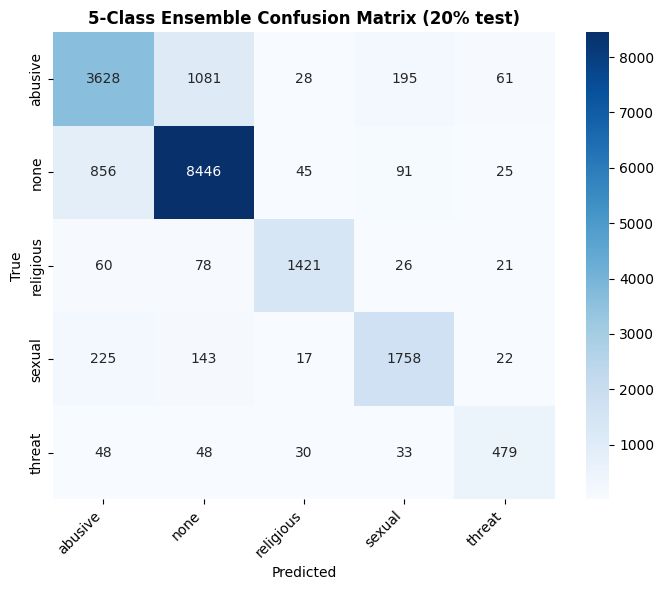

In [8]:
# ── Confusion matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(yt, yp, labels=list(range(NC)))
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"5-Class Ensemble Confusion Matrix (20% test)", fontweight="bold")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT}/cm_ensemble_20pct.png", dpi=150, bbox_inches="tight"); plt.show()